In [8]:
import networkx as nx
import pandas as pd
import itertools
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("nodes.csv")
df2 = pd.read_csv("filtered_nodes.csv")

G = nx.Graph()

# get set of nodes that should be red
red_nodes = set(df2["name"])

for _, row in df.iterrows():
    node_name = row["name"]
    
    color = "red" if node_name in red_nodes else "blue"
    
    G.add_node(
        node_name,
        station=row["station"],
        lat=row["lat"],
        lng=row["lng"],
        color=color
    )

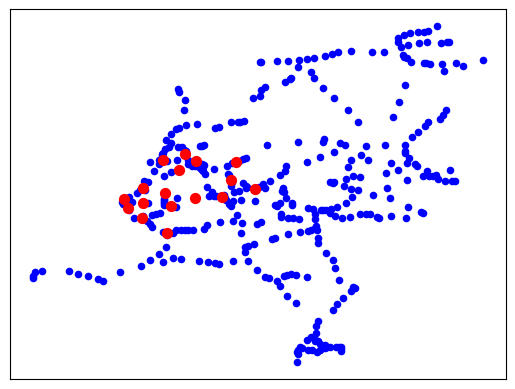

In [10]:
pos = {
    node: (data["lng"], data["lat"])
    for node, data in G.nodes(data=True)
}

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
blue_nodes = [n for n in G.nodes() if G.nodes[n]["color"] != "red"]

# draw blue first
nx.draw_networkx_nodes(
    G, pos,
    nodelist=blue_nodes,
    node_color="blue",
    node_size=20
)

# draw red on top
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50
)

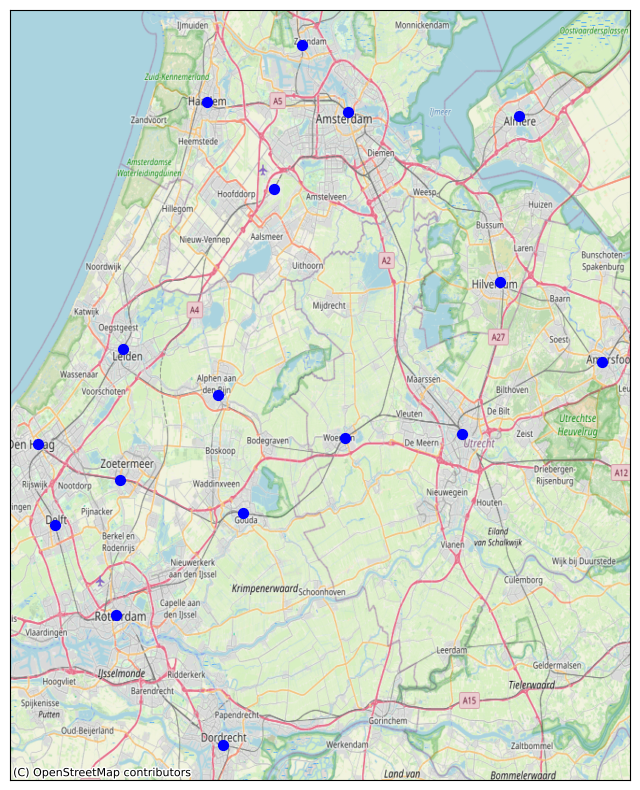

In [27]:
import matplotlib.pyplot as plt
import contextily as ctx

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
# Extract positions
lons = [pos[n][0] for n in red_nodes]
lats = [pos[n][1] for n in red_nodes]

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Draw your red nodes
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50,
    ax=ax
)

# Set bounds roughly around the Netherlands
ax.set_xlim(3, 7.5)
ax.set_ylim(50.5, 53.7)

# Convert axis to Web Mercator (required for basemap)
import geopandas as gpd
from shapely.geometry import Point

points = [Point(pos[n]) for n in G.nodes() if G.nodes[n]["color"] == "red"]
gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326").to_crs(epsg=3857)

ax.clear()

# Plot nodes again in projected coordinates
x = gdf.geometry.x
y = gdf.geometry.y

ax.scatter(x, y, c="blue", s=50)

# Add map tiles
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()

In [12]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [13]:
edges_df = pd.read_csv("edges.csv")

for _, row in edges_df.iterrows():
    n1 = row["from"]
    n2 = row["to"]

    lat1, lon1 = G.nodes[n1]["lat"], G.nodes[n1]["lng"]
    lat2, lon2 = G.nodes[n2]["lat"], G.nodes[n2]["lng"]

    dist = haversine(lat1, lon1, lat2, lon2)

    G.add_edge(n1, n2, weight=dist)

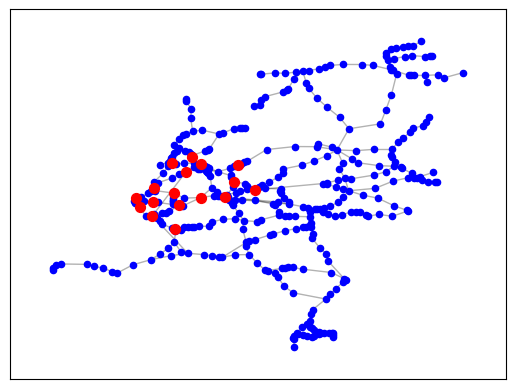

In [14]:
# edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# nodes (layered)
nx.draw_networkx_nodes(G, pos, nodelist=blue_nodes, node_color="blue", node_size=20)
nx.draw_networkx_nodes(G, pos, nodelist=red_nodes, node_color="red", node_size=50)

In [15]:
# all red cities
red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]

results = []

for source, target in itertools.combinations(red_nodes, 2):
    try:
        path = nx.shortest_path(G, source=source, target=target, weight="weight")
        distance = nx.shortest_path_length(G, source=source, target=target, weight="weight")

        results.append({
            "from": source,
            "to": target,
            "distance_km": distance,
            "path": path
        })
    except nx.NetworkXNoPath:
        results.append({
            "from": source,
            "to": target,
            "distance_km": None,
            "path": None
        })

shortest_paths_df = pd.DataFrame(results)

In [16]:
print(shortest_paths_df)

    from   to  distance_km                                               path
0    ALM  APN    43.053440  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, HVSP, ...
1    ALM  AMF    19.382959  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, BRN, AMF]
2    ALM  ASD    21.561287        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
3    ALM   DT    58.697908  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, SH...
4    ALM  GVC    60.727389  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, AS...
..   ...  ...          ...                                                ...
131   UT   ZD    22.032106  [UT, UTZL, MAS, BKL, AC, ASHD, ASB, DVD, ASA, ...
132   UT  ZTM    43.276381  [UT, UTZL, MAS, BKL, WD, GDG, GD, LLZM, ZTMO, ...
133   WD   ZD    20.483704  [WD, BKL, AC, ASHD, ASB, DVD, ASA, ASDM, ASD, ...
134   WD  ZTM    28.482377                     [WD, GDG, GD, LLZM, ZTMO, ZTM]
135   ZD  ZTM    45.151800  [ZD, KZ, ZZS, WM, KMA, UTG, HK, BV, DRH, SPTN,...

[136 rows x 4 columns]


In [17]:
red_set = set(red_nodes)

direct_connections = []

for _, row in shortest_paths_df.iterrows():
    path = row["path"]
    
    if path is None:
        continue

    # only check intermediate nodes, not start/end
    intermediate_nodes = path[1:-1]

    # keep only if all intermediate nodes are blue
    if all(node not in red_set for node in intermediate_nodes):
        direct_connections.append({
            "from": row["from"],
            "to": row["to"],
            "distance_km": row["distance_km"],
            "path": path
        })

red_city_connections_df = pd.DataFrame(direct_connections)



In [18]:
print(red_city_connections_df[10:])

    from    to  distance_km                                               path
10   ASD    UT    16.148262  [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, MAS,...
11   ASD    WD    14.599860      [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, WD]
12   ASD    ZD     5.883844                                     [ASD, ASS, ZD]
13    DT   GVC     4.392149                           [DT, RSW, GVMW, GV, GVC]
14    DT  LEDN    15.090887     [DT, RSW, GVMW, GV, LAA, GVM, VST, DVNK, LEDN]
15    DT   RTD     7.715420                               [DT, DTCP, SDM, RTD]
16   GVC  LEDN    10.699713                   [GVC, LAA, GVM, VST, DVNK, LEDN]
17   GVC   ZTM    10.407587                                [GVC, VB, YPB, ZTM]
18   DDR   RTD    13.699285                [DDR, ZWD, BRD, RLB, RTZ, RTB, RTD]
19   DDR    UT    52.440528  [DDR, DDRS, SDTB, SDT, HBZM, GND, BHDV, GR, AK...
20    GD   RTD    16.139887                      [GD, NWK, CPS, RTA, RTN, RTD]
21    GD    WD    12.938336                         

{'ALM': Text(5.21764, 52.37503, 'ALM'),
 'APN': Text(4.6577777862549, 52.124443054199, 'APN'),
 'AMF': Text(5.3705554008484, 52.153888702393, 'AMF'),
 'ASD': Text(4.9002776145935, 52.378887176514, 'ASD'),
 'DT': Text(4.3563890457153, 52.00666809082, 'DT'),
 'GVC': Text(4.3249998092651, 52.080276489258, 'GVC'),
 'DDR': Text(4.668333530426, 51.807220458984, 'DDR'),
 'GD': Text(4.7044444084167, 52.017501831055, 'GD'),
 'HLM': Text(4.6383333206177, 52.38777923584, 'HLM'),
 'HVS': Text(5.1819443702698, 52.225833892822, 'HVS'),
 'LEDN': Text(4.4816665649414, 52.166110992432, 'LEDN'),
 'RTD': Text(4.468888759613, 51.92499923706, 'RTD'),
 'SHL': Text(4.7619442939758, 52.30944442749, 'SHL'),
 'UT': Text(5.1102776527405, 52.088890075684, 'UT'),
 'WD': Text(4.8936109542847, 52.084999084473, 'WD'),
 'ZD': Text(4.8136110305786, 52.438888549805, 'ZD'),
 'ZTM': Text(4.4772224426269, 52.047500610352, 'ZTM')}

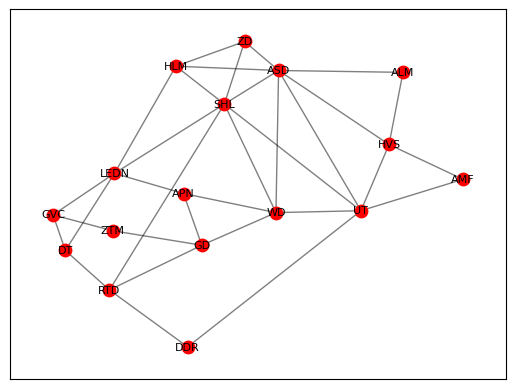

In [19]:
# create reduced graph with only red cities
G_red = nx.Graph()

# add red city nodes with original attributes
for node, data in G.nodes(data=True):
    if data.get("color") == "red":
        G_red.add_node(node, **data)

# add only the filtered red-red connections
for _, row in red_city_connections_df.iterrows():
    G_red.add_edge(
        row["from"],
        row["to"],
        weight=row["distance_km"]
    )

# positions from lat/lon
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}


nx.draw_networkx_edges(G_red, pos_red, alpha=0.5)
nx.draw_networkx_nodes(G_red, pos_red, node_color="red", node_size=80)
nx.draw_networkx_labels(G_red, pos_red, font_size=8)

In [20]:
last_cities = pd.read_csv("last_cities.csv")

for _, row in last_cities.iterrows():
    node_name = row["name"]
    lat = row["lat"]
    lng = row["lng"]

    # add node
    G_red.add_node(
        node_name,
        station=row["station"],
        lat=lat,
        lng=lng,
        color="red"
    )

    # distance to RTD with bus penalty
    lat_rtd = G_red.nodes["RTD"]["lat"]
    lng_rtd = G_red.nodes["RTD"]["lng"]

    weight = 2 * haversine(lat, lng, lat_rtd, lng_rtd)

    # add edge to RTD
    G_red.add_edge(node_name, "RTD", weight=weight, mode="bus")

In [21]:
print(G_red.nodes(data=True))

[('ALM', {'station': 'Almere Centrum', 'lat': 52.37503, 'lng': 5.21764, 'color': 'red'}), ('APN', {'station': 'Alphen a/d Rijn', 'lat': 52.124443054199, 'lng': 4.6577777862549, 'color': 'red'}), ('AMF', {'station': 'Amersfoort Centraal', 'lat': 52.153888702393, 'lng': 5.3705554008484, 'color': 'red'}), ('ASD', {'station': 'Amsterdam Centraal', 'lat': 52.378887176514, 'lng': 4.9002776145935, 'color': 'red'}), ('DT', {'station': 'Delft', 'lat': 52.00666809082, 'lng': 4.3563890457153, 'color': 'red'}), ('GVC', {'station': 'Den Haag Centraal', 'lat': 52.080276489258, 'lng': 4.3249998092651, 'color': 'red'}), ('DDR', {'station': 'Dordrecht', 'lat': 51.807220458984, 'lng': 4.668333530426, 'color': 'red'}), ('GD', {'station': 'Gouda', 'lat': 52.017501831055, 'lng': 4.7044444084167, 'color': 'red'}), ('HLM', {'station': 'Haarlem', 'lat': 52.38777923584, 'lng': 4.6383333206177, 'color': 'red'}), ('HVS', {'station': 'Hilversum', 'lat': 52.225833892822, 'lng': 5.1819443702698, 'color': 'red'}), (

{('ALM', 'ASD'): Text(5.058955826358254, 52.3769586244869, '21.6'),
 ('ALM', 'HVS'): Text(5.199792192648077, 52.300431977813645, '6.5'),
 ('APN', 'GD'): Text(4.6811123856268795, 52.07096949037939, '4.9'),
 ('APN', 'LEDN'): Text(4.569721598588609, 52.14527715983604, '12.0'),
 ('APN', 'WD'): Text(4.775692401555762, 52.10472139861071, '16.1'),
 ('AMF', 'HVS'): Text(5.276249925257742, 52.18986128246456, '12.9'),
 ('AMF', 'UT'): Text(5.2404221683500225, 52.12139079789257, '17.8'),
 ('ASD', 'HLM'): Text(4.769305303790063, 52.38333321173795, '17.8'),
 ('ASD', 'HVS'): Text(5.041114211261212, 52.302358785606664, '19.2'),
 ('ASD', 'SHL'): Text(4.831104952473106, 52.34416278911768, '9.4'),
 ('ASD', 'UT'): Text(5.005278100217785, 52.23388798182114, '16.1'),
 ('ASD', 'WD'): Text(4.896944322378041, 52.23194480296555, '14.6'),
 ('ASD', 'ZD'): Text(4.856943974222069, 52.40888810434031, '5.9'),
 ('DT', 'GVC'): Text(4.340694420240291, 52.04347230704018, '4.4'),
 ('DT', 'LEDN'): Text(4.419029567860834, 5

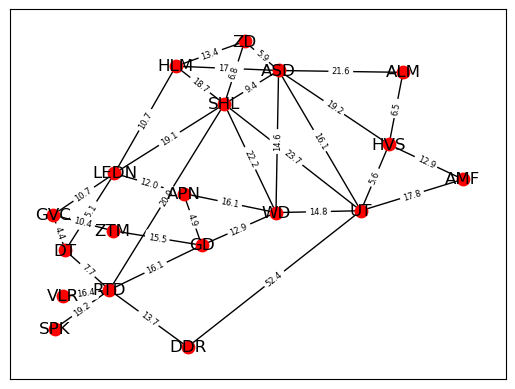

In [30]:
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}

nx.draw_networkx(G_red, pos_red, with_labels=True, node_color="red", node_size=80)

# add edge weights (rounded)
edge_labels = {
    (u, v): f"{data['weight']:.1f}"
    for u, v, data in G_red.edges(data=True)
}

nx.draw_networkx_edge_labels(G_red, pos_red, edge_labels=edge_labels, font_size=6)

['ALM', 'APN', 'AMF', 'ASD', 'DT', 'GVC', 'DDR', 'GD', 'HLM', 'HVS', 'LEDN', 'RTD', 'SHL', 'UT', 'WD', 'ZD', 'ZTM', 'SPK', 'VLR']


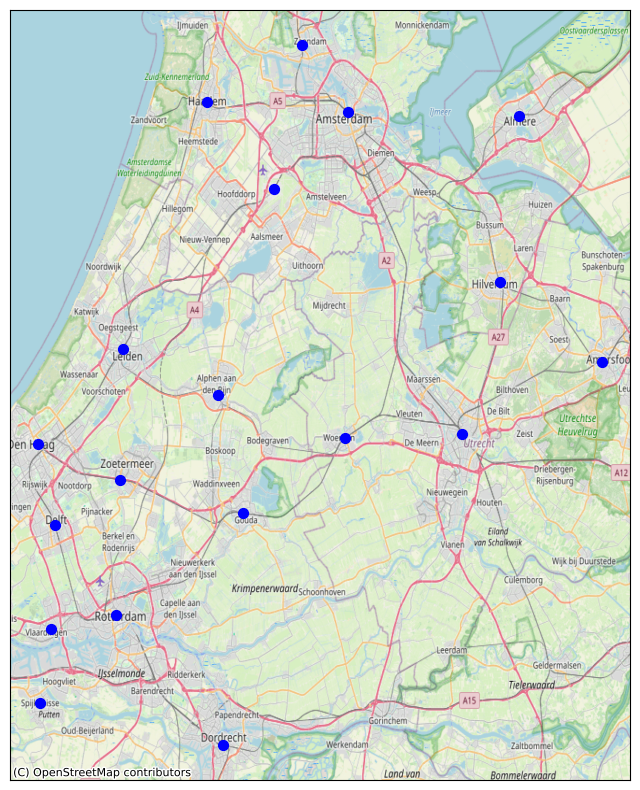

In [33]:
import matplotlib.pyplot as plt
import contextily as ctx

red_nodes = [n for n in G_red.nodes()]
print(red_nodes)
# Extract positions
lons = [pos_red[n][0] for n in red_nodes]
lats = [pos_red[n][1] for n in red_nodes]

# Create plot
fig, ax = plt.subplots(figsize=(8, 10))

# Draw your red nodes
nx.draw_networkx_nodes(
    G_red, pos_red,
    nodelist=red_nodes,
    node_color="red",
    node_size=50,
    ax=ax
)

# Set bounds roughly around the Netherlands
ax.set_xlim(3, 7.5)
ax.set_ylim(50.5, 53.7)

# Convert axis to Web Mercator (required for basemap)
import geopandas as gpd
from shapely.geometry import Point

points = [Point(pos_red[n]) for n in G_red.nodes()]
gdf = gpd.GeoDataFrame(geometry=points, crs="EPSG:4326").to_crs(epsg=3857)

ax.clear()

# Plot nodes again in projected coordinates
x = gdf.geometry.x
y = gdf.geometry.y

ax.scatter(x, y, c="blue", s=50)

# Add map tiles
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.show()

In [23]:
# =============================================================
# Network Metrics Table
# Computed on G_red (reduced graph of red/key-city nodes)
# Dyadicity computed on the full graph G (red vs blue nodes)
# =============================================================

# ------------------------------------------------------------------
# 1. Degree Centrality of Nodes (DCS)
#    Fraction of other nodes each node is connected to.
# ------------------------------------------------------------------
dcs = nx.degree_centrality(G_red)

# ------------------------------------------------------------------
# 2. Closeness Centrality of Nodes (CCN)
#    How close a node is to all others (uses edge weights as distances).
#    A larger weight means a longer path, so shorter distances => higher
#    centrality is preserved by passing distance='weight'.
# ------------------------------------------------------------------
ccn = nx.closeness_centrality(G_red, distance='weight')

# ------------------------------------------------------------------
# 3. Betweenness Centrality of Nodes (BCN)
#    Fraction of all-pairs shortest paths that pass through each node.
#    Normalised to [0, 1].
# ------------------------------------------------------------------
bcn = nx.betweenness_centrality(G_red, weight='weight', normalized=True)

# ------------------------------------------------------------------
# 4. Local Clustering Coefficient of Nodes (LCN)
#    Fraction of a node's neighbours that are also connected to each other.
#    Weighted variant accounts for edge strengths.
# ------------------------------------------------------------------
lcn = nx.clustering(G_red, weight='weight')

# ------------------------------------------------------------------
# 5. Dyadicity (graph-level scalar)
#    Ratio of observed same-type edges to the expected number in a random
#    graph with the same degree sequence.
#      D > 1  ->  assortative (same-type nodes connect more than by chance)
#      D < 1  ->  disassortative
#      D = 1  ->  random mixing
#    Computed on the full graph G where nodes are typed 'red' or 'blue'.
# ------------------------------------------------------------------
def compute_dyadicity(G, attribute='color'):
    """Return dyadicity for a graph whose nodes carry a categorical attribute."""
    nodes = list(G.nodes())
    n = len(nodes)
    m = G.number_of_edges()
    if n < 2 or m == 0:
        return None
    # count nodes per type
    type_counts = {}
    for node in nodes:
        t = G.nodes[node].get(attribute, 'unknown')
        type_counts[t] = type_counts.get(t, 0) + 1
    # actual same-type edges
    same_type_edges = sum(
        1 for u, v in G.edges()
        if G.nodes[u].get(attribute) == G.nodes[v].get(attribute)
    )
    # expected same-type edges under random graph with same n, m
    expected_same = m * sum(c * (c - 1) for c in type_counts.values()) / (n * (n - 1))
    return same_type_edges / expected_same if expected_same > 0 else None

dyadicity = compute_dyadicity(G, attribute='color')

# ------------------------------------------------------------------
# Build and display the combined metrics table
# ------------------------------------------------------------------
metrics_df = pd.DataFrame({
    'Node': list(G_red.nodes()),
    'Station': [G_red.nodes[n]['station'] for n in G_red.nodes()],
    'DCS':  [round(dcs[n],  4) for n in G_red.nodes()],
    'CCN':  [round(ccn[n],  4) for n in G_red.nodes()],
    'BCN':  [round(bcn[n],  4) for n in G_red.nodes()],
    'LCN':  [round(lcn[n],  4) for n in G_red.nodes()],
})

metrics_df = metrics_df.sort_values('DCS', ascending=False).reset_index(drop=True)

print("=" * 70)
print("NETWORK METRICS TABLE  (G_red — key-city subgraph)")
print("=" * 70)
print(metrics_df.to_string(index=False))
print()
print("Columns:")
print("  DCS  Degree Centrality          – fraction of nodes this node connects to")
print("  CCN  Closeness Centrality       – inverse avg. shortest weighted path length")
print("  BCN  Betweenness Centrality     – fraction of shortest paths through node")
print("  LCN  Local Clustering Coeff.   – fraction of neighbours that are mutually connected")
print()
print("-" * 70)
print(f"Dyadicity (full graph G, red vs blue):  {dyadicity:.4f}")
print("  D < 1 → fewer same-type edges than expected by chance (disassortative)")
print("  D = 1 → random mixing")
print("  D > 1 → more same-type edges than expected by chance (assortative)")
print("-" * 70)


NETWORK METRICS TABLE  (G_red — key-city subgraph)
Node             Station    DCS    CCN    BCN    LCN
 ASD  Amsterdam Centraal 0.3889 0.0353 0.2092 0.0944
 SHL    Schiphol Airport 0.3889 0.0364 0.1830 0.0899
 RTD  Rotterdam Centraal 0.3333 0.0364 0.3464 0.0000
  UT    Utrecht Centraal 0.3333 0.0293 0.0980 0.0931
  WD             Woerden 0.2778 0.0352 0.1111 0.1136
LEDN     Leiden Centraal 0.2778 0.0341 0.1503 0.0468
  GD               Gouda 0.2222 0.0372 0.1046 0.0320
 HVS           Hilversum 0.2222 0.0267 0.1111 0.1170
 HLM             Haarlem 0.2222 0.0318 0.0784 0.1696
 APN     Alphen a/d Rijn 0.1667 0.0349 0.0261 0.0640
  ZD             Zaandam 0.1667 0.0344 0.0000 0.1928
  DT               Delft 0.1667 0.0320 0.1046 0.0567
 GVC   Den Haag Centraal 0.1667 0.0311 0.0588 0.0567
 AMF Amersfoort Centraal 0.1111 0.0202 0.0000 0.2072
 ALM      Almere Centrum 0.1111 0.0242 0.0000 0.2654
 DDR           Dordrecht 0.1111 0.0252 0.0000 0.0000
 ZTM          Zoetermeer 0.1111 0.0291 0.0065 0.

In [24]:
#Calculate the weighted edge betweenness centrality, normalize
edge_betweenness_weighted = nx.edge_betweenness_centrality(G_red, 
                                                             k=None, 
                                                             normalized=True, 
                                                             weight='weight', 
                                                             seed=None)
edge_betweenness_weighted

{('ALM', 'ASD'): 0.05847953216374269,
 ('ALM', 'HVS'): 0.04678362573099415,
 ('APN', 'GD'): 0.04678362573099415,
 ('APN', 'LEDN'): 0.05847953216374269,
 ('APN', 'WD'): 0.04678362573099415,
 ('AMF', 'HVS'): 0.07017543859649122,
 ('AMF', 'UT'): 0.03508771929824561,
 ('ASD', 'HLM'): 0.08187134502923976,
 ('ASD', 'HVS'): 0.11695906432748537,
 ('ASD', 'SHL'): 0.12280701754385964,
 ('ASD', 'UT'): 0.017543859649122806,
 ('ASD', 'WD'): 0.04093567251461988,
 ('ASD', 'ZD'): 0.04093567251461988,
 ('DT', 'GVC'): 0.05847953216374269,
 ('DT', 'LEDN'): 0.06432748538011696,
 ('DT', 'RTD'): 0.1695906432748538,
 ('GVC', 'LEDN'): 0.08771929824561403,
 ('GVC', 'ZTM'): 0.06432748538011696,
 ('DDR', 'RTD'): 0.08187134502923976,
 ('DDR', 'UT'): 0.023391812865497075,
 ('GD', 'RTD'): 0.08187134502923976,
 ('GD', 'WD'): 0.1111111111111111,
 ('GD', 'ZTM'): 0.05263157894736842,
 ('HLM', 'LEDN'): 0.1286549707602339,
 ('HLM', 'SHL'): 0.005847953216374269,
 ('HLM', 'ZD'): 0.029239766081871343,
 ('HVS', 'UT'): 0.0701

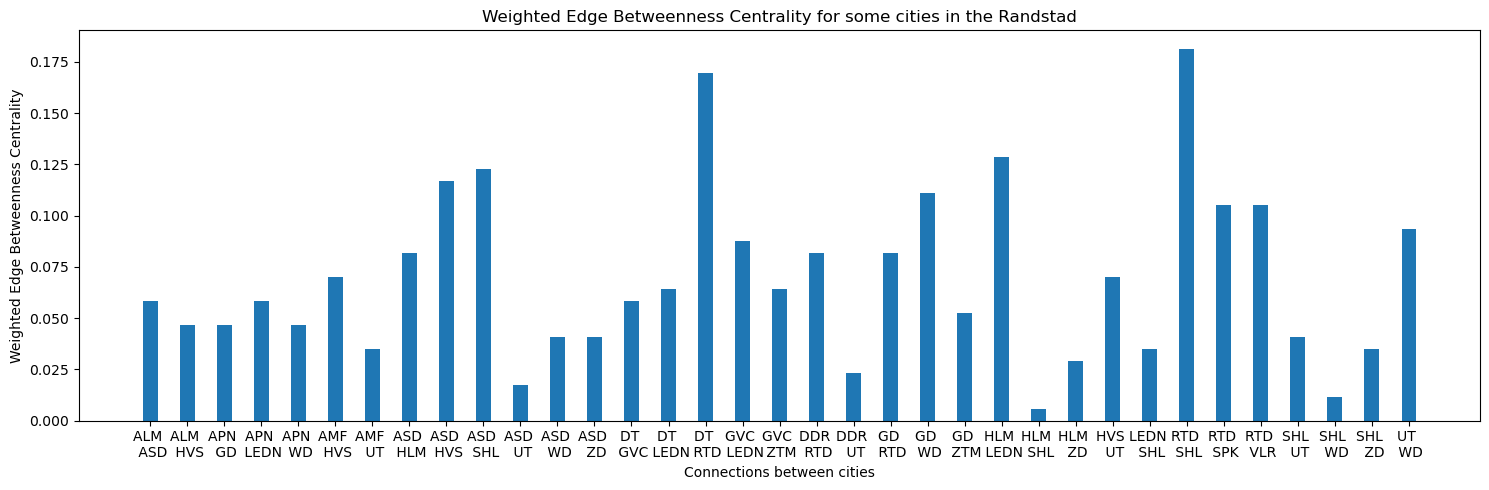

In [25]:
# Helper function for parsing the edge labels
def ppEdges (l):
    rl = []
    for i in range(len(l)):
        rl.append(str(l[i][0]) + ' \n ' + str(l[i][1]))
    return rl

# Plot the values in a bar chart
plt.figure(figsize=(15, 5))
plt.bar(range(len(edge_betweenness_weighted)), edge_betweenness_weighted.values(), width=0.4)
plt.xticks(range(len(edge_betweenness_weighted)), ppEdges(list(edge_betweenness_weighted.keys())))
plt.title("Weighted Edge Betweenness Centrality for some cities in the Randstad")
plt.xlabel("Connections between cities")
plt.ylabel("Weighted Edge Betweenness Centrality")
plt.tight_layout()